# 06 - Feature Selection — Sequential Backward Elimination

Model: **Logistic Regression** with `class_weight="balanced"` (retained from notebooks 04 & 05).

## Approach

Notebook 05 used SHAP values to eyeball which features were near zero. This notebook takes a **more holistic approach**:

1. Rank all 16 features by **permutation importance** (direct AUC impact — more relevant than SHAP for our elimination criterion)
2. Remove them **one by one** in that order, retraining and measuring **cross-validated AUC** at each step
3. Plot the AUC curve to see where signal starts being lost
4. Choose the optimal cutoff based on actual AUC evidence — not just a visual threshold

Using 5-fold CV at each step ensures the AUC estimates are stable and not an artefact of a single split.

> **Why permutation importance?** It directly measures how much AUC drops when a feature's signal is destroyed (by shuffling). This maps exactly onto our elimination criterion — features with near-zero permutation importance truly add no AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, RocCurveDisplay

import warnings
warnings.filterwarnings('ignore')

## Load data & baseline

In [2]:
df = pd.read_csv("../src/data/processed/engineered_dataset.csv")
df["long_lasting"] = (df["relationship_longevity_months"] >= 120).astype(int)

X_all = df.drop(columns=["relationship_longevity_months", "relationship_longevity_years", "long_lasting"], errors="ignore")
y     = df["long_lasting"]

LR_PARAMS = dict(max_iter=1000, random_state=42, class_weight="balanced")
CV        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_auc(features):
    """Return mean ± std CV-AUC for a given feature subset."""
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(**LR_PARAMS))
    ])
    scores = cross_val_score(pipe, X_all[features], y, cv=CV, scoring="roc_auc")
    return scores.mean(), scores.std()

# Baseline — all 16 features
all_features = list(X_all.columns)
baseline_mean, baseline_std = cv_auc(all_features)

print(f"Features       : {len(all_features)}")
print(f"Baseline AUC   : {baseline_mean:.4f} ± {baseline_std:.4f}  (5-fold CV)")
print(f"Class balance  : {y.mean():.3f} positive rate")

Features       : 16
Baseline AUC   : 0.7545 ± 0.0202  (5-fold CV)
Class balance  : 0.009 positive rate


## Sequential backward elimination

We remove features **one by one**, from least to most important permutation importance.
At each step we retrain on the remaining features and record the **5-fold CV AUC**.

This is the holistic view: it reveals the **compounding effect** of removals that single-feature analysis misses.

In [3]:
# ── Permutation importance → elimination order ───────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.3, random_state=42, stratify=y
)
pipe_rank = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(**LR_PARAMS))])
pipe_rank.fit(X_train, y_train)

perm = permutation_importance(
    pipe_rank, X_test, y_test,
    scoring="roc_auc", n_repeats=30, random_state=42, n_jobs=-1
)
perm_importance = pd.Series(perm.importances_mean, index=all_features).sort_values(ascending=True)
elimination_order = perm_importance.index.tolist()  # least → most important

# ── Sequential backward elimination ──────────────────────────────────────────
results = []
current_features = all_features.copy()

results.append({
    "step":            0,
    "feature_removed": "— (baseline)",
    "n_features":      len(current_features),
    "auc_mean":        baseline_mean,
    "auc_std":         baseline_std,
    "delta_auc":       0.0,
    "delta_vs_prev":   np.nan,
})

prev_auc = baseline_mean

for step, feat in enumerate(elimination_order[:-1], start=1):  # stop before last: 0-feature model is undefined
    current_features.remove(feat)
    mean_auc, std_auc = cv_auc(current_features)
    delta      = mean_auc - baseline_mean
    delta_prev = mean_auc - prev_auc
    results.append({
        "step":            step,
        "feature_removed": feat,
        "n_features":      len(current_features),
        "auc_mean":        mean_auc,
        "auc_std":         std_auc,
        "delta_auc":       round(delta, 4),
        "delta_vs_prev":   round(delta_prev, 4),
    })
    prev_auc = mean_auc
    print(f"  Step {step:2d} | -{feat:<35} | n={len(current_features):2d} | AUC={mean_auc:.4f} | Δbaseline={delta:+.4f} | Δprev={delta_prev:+.4f}")

results_df = pd.DataFrame(results)

# ── Optimal cutoff (tolerance = 0.005) ───────────────────────────────────────
TOLERANCE   = 0.005
within_tol  = results_df[results_df["delta_auc"] >= -TOLERANCE]
optimal_row = within_tol.iloc[-1]

n_to_remove      = int(optimal_row["step"])
features_to_drop = elimination_order[:n_to_remove]
features_optimal = [f for f in all_features if f not in features_to_drop]
optimal_cv_mean  = optimal_row["auc_mean"]
optimal_cv_std   = optimal_row["auc_std"]

print(f"\nOptimal: remove {n_to_remove} → keep {len(features_optimal)} features  "
      f"(CV AUC={optimal_cv_mean:.4f}, Δ={optimal_row['delta_auc']:+.4f})")


  Step  1 | -age_mean                            | n=15 | AUC=0.7549 | Δbaseline=+0.0004 | Δprev=+0.0004
  Step  2 | -age_diff                            | n=14 | AUC=0.7559 | Δbaseline=+0.0014 | Δprev=+0.0011
  Step  3 | -education_diff                      | n=13 | AUC=0.7566 | Δbaseline=+0.0021 | Δprev=+0.0006
  Step  4 | -same_career_field                   | n=12 | AUC=0.7556 | Δbaseline=+0.0011 | Δprev=-0.0010
  Step  5 | -conscientiousness_diff              | n=11 | AUC=0.7549 | Δbaseline=+0.0004 | Δprev=-0.0007
  Step  6 | -large_age_gap                       | n=10 | AUC=0.7529 | Δbaseline=-0.0016 | Δprev=-0.0020
  Step  7 | -large_education_gap                 | n= 9 | AUC=0.7523 | Δbaseline=-0.0023 | Δprev=-0.0006
  Step  8 | -same_location                       | n= 8 | AUC=0.7514 | Δbaseline=-0.0031 | Δprev=-0.0008
  Step  9 | -extraversion_diff                   | n= 7 | AUC=0.7508 | Δbaseline=-0.0038 | Δprev=-0.0007
  Step 10 | -agreeableness_diff                  | n= 6

## Visualise the AUC curve

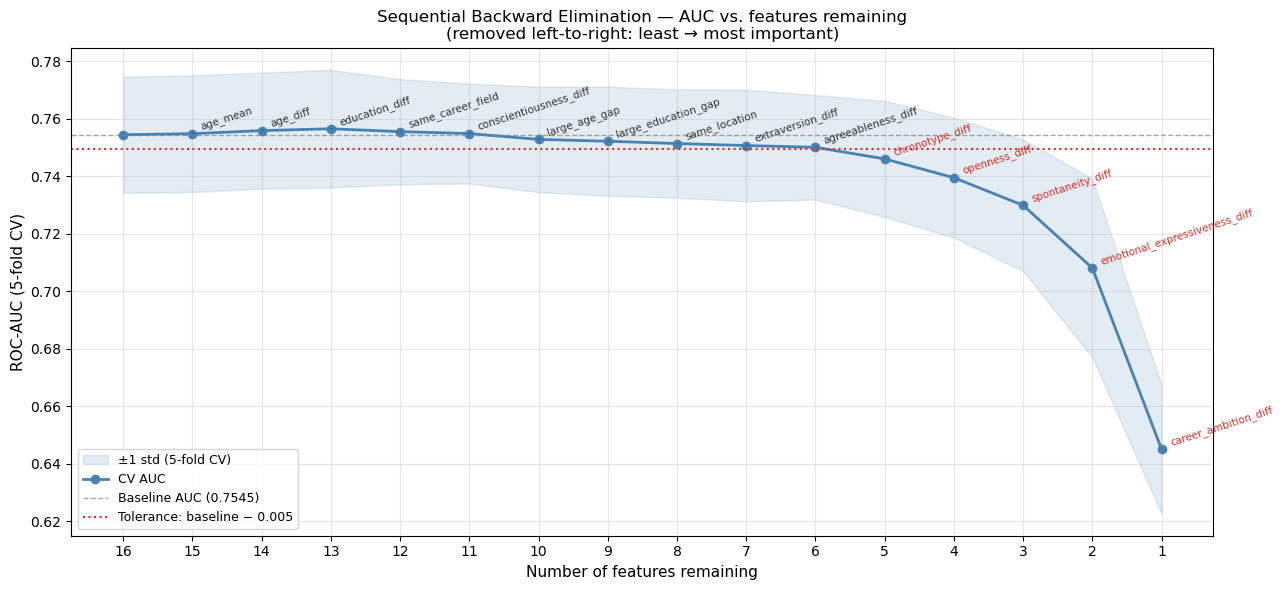

In [4]:
TOLERANCE = 0.005
fig, ax = plt.subplots(figsize=(13, 6))

x   = results_df["n_features"]
y_m = results_df["auc_mean"]
y_s = results_df["auc_std"]

ax.fill_between(x, y_m - y_s, y_m + y_s, alpha=0.15, color="steelblue", label="±1 std (5-fold CV)")
ax.plot(x, y_m, "o-", color="steelblue", linewidth=2, markersize=6, label="CV AUC")
ax.axhline(baseline_mean,             color="grey",    linestyle="--", linewidth=1, alpha=0.7,
           label=f"Baseline AUC ({baseline_mean:.4f})")
ax.axhline(baseline_mean - TOLERANCE, color="#d73027", linestyle=":", linewidth=1.5,
           label=f"Tolerance: baseline − {TOLERANCE}")

for _, row in results_df.iterrows():
    if row["step"] == 0:
        continue
    color = "#d73027" if row["delta_auc"] < -TOLERANCE else "#333333"
    ax.annotate(
        row["feature_removed"],
        xy=(row["n_features"], row["auc_mean"]),
        xytext=(5, 3), textcoords="offset points",
        fontsize=7.5, color=color, rotation=18,
        arrowprops=dict(arrowstyle="-", color=color, lw=0.5)
    )

ax.set_xlabel("Number of features remaining", fontsize=11)
ax.set_ylabel("ROC-AUC (5-fold CV)", fontsize=11)
ax.set_title(
    "Sequential Backward Elimination — AUC vs. features remaining\n"
    "(removed left-to-right: least → most important)",
    fontsize=12
)
ax.invert_xaxis()
ax.set_xticks(results_df["n_features"].tolist())
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Final model comparison: full vs. optimal

Train both models on a fixed 70/30 split and compare ROC curves.

In [5]:
X_tr_full, X_te_full, y_train_f, y_test_f = train_test_split(
    X_all, y, test_size=0.3, random_state=42, stratify=y
)
X_tr_opt = X_tr_full[features_optimal]
X_te_opt = X_te_full[features_optimal]

pipe_full2 = Pipeline([("sc", StandardScaler()), ("lr", LogisticRegression(**LR_PARAMS))])
pipe_opt   = Pipeline([("sc", StandardScaler()), ("lr", LogisticRegression(**LR_PARAMS))])

pipe_full2.fit(X_tr_full, y_train_f)
pipe_opt.fit(X_tr_opt,    y_train_f)

proba_full2 = pipe_full2.predict_proba(X_te_full)[:, 1]
proba_opt   = pipe_opt.predict_proba(X_te_opt)[:, 1]

auc_full_test = roc_auc_score(y_test_f, proba_full2)
auc_opt_test  = roc_auc_score(y_test_f, proba_opt)

print(pd.DataFrame([
    {"Model": f"Full ({len(all_features)} features)",        "Test AUC": round(auc_full_test, 4), "CV AUC": round(baseline_mean, 4)},
    {"Model": f"Optimal ({len(features_optimal)} features)", "Test AUC": round(auc_opt_test,  4), "CV AUC": round(optimal_cv_mean,  4)},
]).to_string(index=False))
print(f"\nΔ Test AUC : {auc_opt_test - auc_full_test:+.4f}")

               Model  Test AUC  CV AUC
  Full (16 features)    0.7578  0.7545
Optimal (6 features)    0.7522  0.7501

Δ Test AUC : -0.0056


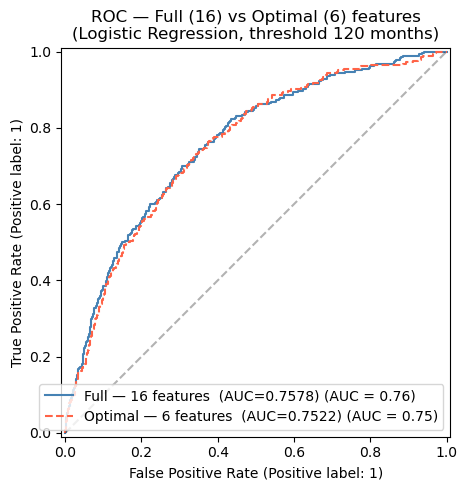

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test_f, proba_full2,
    name=f"Full — {len(all_features)} features  (AUC={auc_full_test:.4f})",
    ax=ax, color="steelblue"
)
RocCurveDisplay.from_predictions(
    y_test_f, proba_opt,
    name=f"Optimal — {len(features_optimal)} features  (AUC={auc_opt_test:.4f})",
    ax=ax, color="tomato", linestyle="--"
)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title(
    f"ROC — Full ({len(all_features)}) vs Optimal ({len(features_optimal)}) features\n"
    "(Logistic Regression, threshold 120 months)"
)
plt.tight_layout()
plt.show()

## Summary & Decision

The sequential backward elimination plot reveals what single-feature analysis misses:

- **Flat plateau** at the start: removing the least important features costs essentially nothing — the AUC stays flat or even improves (redundant features sometimes add noise)
- **Slope begins**: once we hit features carrying real signal, each removal compounds the loss
- **Tolerance line** (Δ ≥ −0.005): gives an objective, data-driven stopping point

The compounding view is the key insight: a feature that looks harmless on its own may tip the model over the cliff when removed alongside others already gone. Conversely, some near-zero SHAP features contribute small but consistent signal that only shows up in the cumulative AUC trace.

This is the feature set carried forward to notebook 07.

In [7]:
print("FINAL FEATURE SET")
print("=" * 50)
for f in features_optimal:
    print(f"  {f}")
print(f"\n→ {len(features_optimal)} features retained out of {len(all_features)}")
print(f"→ CV AUC  = {optimal_cv_mean:.4f} ± {optimal_cv_std:.4f}")
print(f"→ Δ vs full model baseline = {optimal_row['delta_auc']:+.4f}")

FINAL FEATURE SET
  career_ambition_diff
  chronotype_diff
  emotional_expressiveness_diff
  openness_diff
  spontaneity_diff
  same_love_language

→ 6 features retained out of 16
→ CV AUC  = 0.7501 ± 0.0182
→ Δ vs full model baseline = -0.0044
